# Cab Companion — ML & Data Analysis

**Disclosure:** The datasets in this notebook are synthetic and calibrated from patterns in the hackathon sample. The pipeline and evaluation code are real; the results are not claims of production CAT performance.

In [1]:
from pathlib import Path
import json
import sys
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

ROOT = Path.cwd() if (Path.cwd() / 'ml').exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
from ml.train import build_anomaly_windows
from backend.features import WINDOW_FEATURES

DATA = ROOT / 'ml' / 'data'
MODELS = ROOT / 'ml' / 'models'
tasks = pd.read_csv(DATA / 'tasks.csv')
telemetry = pd.read_csv(DATA / 'telemetry.csv')
meta = json.loads((MODELS / 'meta.json').read_text())
plt.style.use('seaborn-v0_8-whitegrid')
COLORS = {'planned': '#66717e', 'actual': '#f2b705', 'safe': '#2f6fb5', 'unsafe': '#cc2f35'}

## A. Dataset overview
The five `brief` rows are shown only as a sanity check. Model validation uses held-out rows from the 2,000-row synthetic task set.

In [2]:
overview = pd.DataFrame({
    'Measure': ['Task rows', 'Synthetic task rows', 'Brief sanity rows', 'Telemetry rows',
                'Task types', 'Weather categories', 'Operator skill categories',
                'Mean overrun ratio', 'Median overrun ratio'],
    'Value': [len(tasks), (tasks.source == 'synthetic').sum(), (tasks.source == 'brief').sum(),
              len(telemetry), tasks.task_type.nunique(), tasks.weather.nunique(),
              tasks.operator_skill.nunique(),
              round((tasks.actual_min / tasks.estimated_min).mean(), 3),
              round((tasks.actual_min / tasks.estimated_min).median(), 3)]
})
display(overview)
print('Task types:', ', '.join(sorted(tasks.task_type.unique())))
print('Weather:', ', '.join(sorted(tasks.weather.unique())))
print('Skills:', ', '.join(sorted(tasks.operator_skill.unique())))
display(tasks[['estimated_min', 'actual_min']].describe().round(2))

,Measure,Value
0,Task rows,2005.000
1,Synthetic task rows,2000.000
2,Brief sanity rows,5.000
3,Telemetry rows,4200.000
4,Task types,5.000
5,Weather categories,4.000
6,Operator skill categories,3.000
7,Mean overrun ratio,1.177
8,Median overrun ratio,1.139


Task types: Demolition, Earth Excavation, Grading, Material Loading, Trenching
Weather: Cloudy, Rainy, Sunny, Windy
Skills: Beginner, Expert, Intermediate


,estimated_min,actual_min
count,2005.00,2005.00
mean,56.59,66.92
std,28.85,36.64
min,20.00,17.00
25%,35.00,41.00
50%,50.00,57.00
75%,70.00,83.00
max,150.00,235.00


## B. Actual vs planned time by operator skill

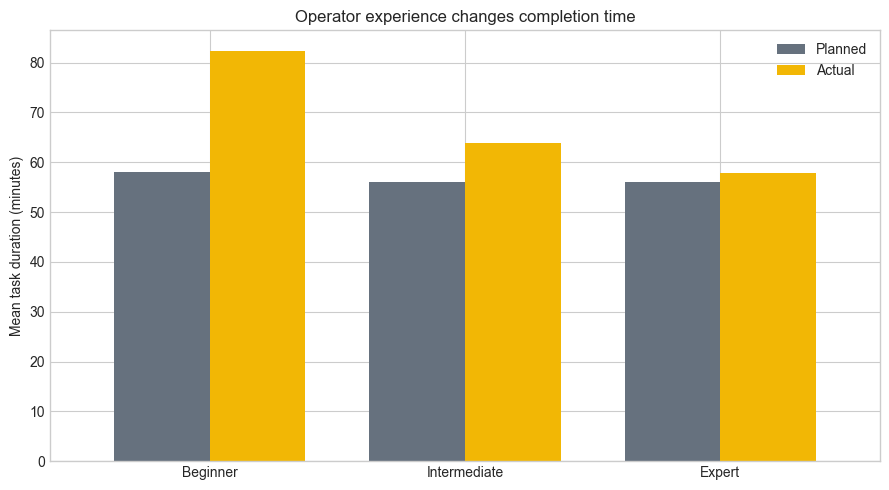

,estimated_min,actual_min
operator_skill,,
Beginner,58.1,82.3
Intermediate,56.1,64.0
Expert,56.0,57.9


In [3]:
skill_order = ['Beginner', 'Intermediate', 'Expert']
skill_duration = tasks.groupby('operator_skill')[['estimated_min', 'actual_min']].mean().reindex(skill_order)
ax = skill_duration.rename(columns={'estimated_min': 'Planned', 'actual_min': 'Actual'}).plot(
    kind='bar', figsize=(9, 5), color=[COLORS['planned'], COLORS['actual']], width=0.75)
ax.set(title='Operator experience changes completion time', xlabel='', ylabel='Mean task duration (minutes)')
ax.tick_params(axis='x', rotation=0)
ax.legend(frameon=False)
plt.tight_layout(); plt.show()
display(skill_duration.round(1))

## C. Actual vs planned time by weather

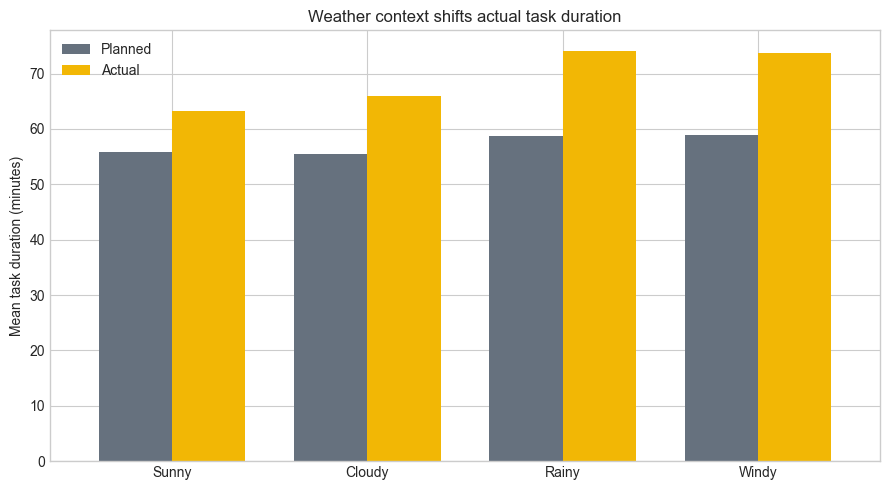

,estimated_min,actual_min
weather,,
Sunny,55.8,63.2
Cloudy,55.5,66.0
Rainy,58.7,74.1
Windy,59.0,73.7


In [4]:
weather_order = ['Sunny', 'Cloudy', 'Rainy', 'Windy']
weather_duration = tasks.groupby('weather')[['estimated_min', 'actual_min']].mean().reindex(weather_order)
ax = weather_duration.rename(columns={'estimated_min': 'Planned', 'actual_min': 'Actual'}).plot(
    kind='bar', figsize=(9, 5), color=[COLORS['planned'], COLORS['actual']], width=0.75)
ax.set(title='Weather context shifts actual task duration', xlabel='', ylabel='Mean task duration (minutes)')
ax.tick_params(axis='x', rotation=0)
ax.legend(frameon=False)
plt.tight_layout(); plt.show()
display(weather_duration.round(1))

## D. Task overrun ratio
The target is `actual_min / estimated_min`: 1.0 means on plan, 1.2 means 20% over plan. This normalizes tasks with very different planned durations.

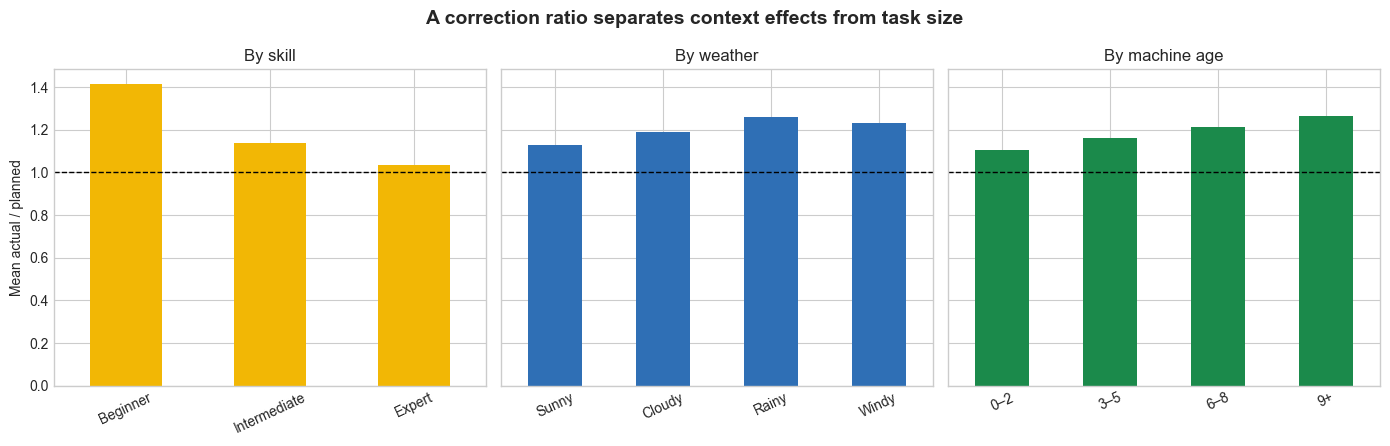

In [5]:
task_view = tasks.assign(overrun_ratio=tasks.actual_min / tasks.estimated_min,
                         age_band=pd.cut(tasks.machine_age, [-1, 2, 5, 8, 20], labels=['0–2', '3–5', '6–8', '9+']))
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=True)
task_view.groupby('operator_skill').overrun_ratio.mean().reindex(skill_order).plot.bar(
    ax=axes[0], color=COLORS['actual'], title='By skill')
task_view.groupby('weather').overrun_ratio.mean().reindex(weather_order).plot.bar(
    ax=axes[1], color='#2f6fb5', title='By weather')
task_view.groupby('age_band', observed=True).overrun_ratio.mean().plot.bar(
    ax=axes[2], color='#1b8a4b', title='By machine age')
for ax in axes:
    ax.axhline(1, color='black', linewidth=1, linestyle='--')
    ax.set(xlabel='', ylabel='Mean actual / planned')
    ax.tick_params(axis='x', rotation=25)
fig.suptitle('A correction ratio separates context effects from task size', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## E. Isolation Forest anomaly scores
The model is fitted on the first five synthetic shift days and evaluated on the final two days. Lower scores are more anomalous; zero is the Isolation Forest decision boundary.

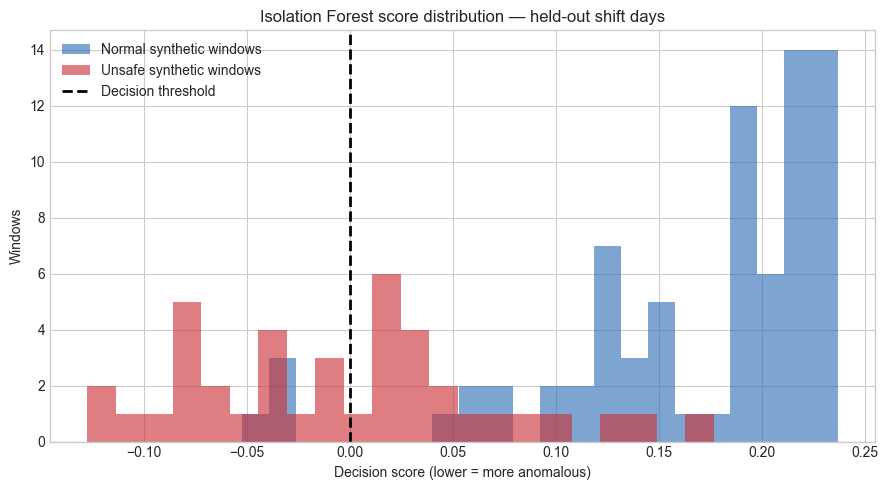

{'features': ['idle_share',
  'fuel_per_cycle',
  'unbelted_min',
  'cycles',
  'harsh_count'],
 'window_rows': 30,
 'window_semantics': '30 consecutive one-minute telemetry rows',
 'train_windows': 290,
 'test_windows': 116,
 'windows': 116,
 'test_days': ['2025-05-06', '2025-05-07'],
 'decision_threshold': 0.0,
 'flag_rate': 0.207,
 'precision_vs_labelled_unsafe': 0.833,
 'recall_vs_labelled_unsafe': 0.5,
 'evaluation_note': 'held-out synthetic days; not production performance'}

In [6]:
windows = build_anomaly_windows(telemetry)
test_days = set(meta['anomaly_model']['test_days'])
anomaly_test = windows[windows.day.isin(test_days)].copy()
iso = joblib.load(MODELS / 'usage_iforest.joblib')
anomaly_test['score'] = iso.decision_function(anomaly_test[WINDOW_FEATURES])
anomaly_test['flagged'] = iso.predict(anomaly_test[WINDOW_FEATURES]) == -1
fig, ax = plt.subplots(figsize=(9, 5))
for label, colour, name in [(0, COLORS['safe'], 'Normal synthetic windows'),
                            (1, COLORS['unsafe'], 'Unsafe synthetic windows')]:
    anomaly_test.loc[anomaly_test.unsafe == label, 'score'].plot.hist(
        bins=22, alpha=0.62, ax=ax, color=colour, label=name)
ax.axvline(0, color='black', linestyle='--', linewidth=2, label='Decision threshold')
ax.set(title='Isolation Forest score distribution — held-out shift days',
       xlabel='Decision score (lower = more anomalous)', ylabel='Windows')
ax.legend(frameon=False)
plt.tight_layout(); plt.show()
display(meta['anomaly_model'])

## F. Interval calibration

,Model,Coverage,Mean width (min),Median MAE (min)
0,Baseline q10–q90,0.625,8.09,3.61
1,Final q05–q95,0.797,11.74,3.57


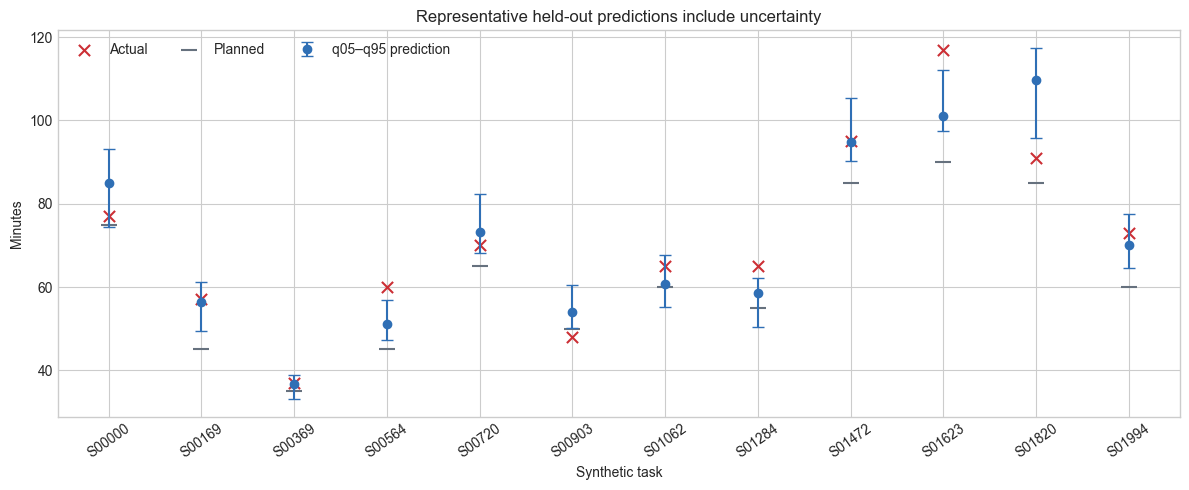

In [7]:
task_meta = meta['task_model']
calibration = pd.DataFrame([
    {'Model': 'Baseline q10–q90', 'Coverage': task_meta['baseline']['coverage'],
     'Mean width (min)': task_meta['baseline']['mean_interval_width_min'],
     'Median MAE (min)': task_meta['baseline']['mae_model_min']},
    {'Model': 'Final q05–q95', 'Coverage': task_meta['interval_coverage'],
     'Mean width (min)': task_meta['mean_interval_width_min'],
     'Median MAE (min)': task_meta['mae_model_min']}
])
display(calibration)
sample = pd.DataFrame(task_meta['representative_holdout_rows'])
x = np.arange(len(sample))
fig, ax = plt.subplots(figsize=(12, 5))
ax.errorbar(x, sample['median'], yerr=[sample['median'] - sample['lower'],
                                               sample['upper'] - sample['median']],
            fmt='o', capsize=4, color=COLORS['safe'], label='q05–q95 prediction')
ax.scatter(x, sample['actual'], marker='x', s=65, color=COLORS['unsafe'], label='Actual')
ax.scatter(x, sample['planned'], marker='_', s=120, color=COLORS['planned'], label='Planned')
ax.set_xticks(x, sample.task_id, rotation=35)
ax.set(title='Representative held-out predictions include uncertainty',
       xlabel='Synthetic task', ylabel='Minutes')
ax.legend(frameon=False, ncol=3)
plt.tight_layout(); plt.show()

## G. Slide-ready findings

In [8]:
ratio_by_skill = task_view.groupby('operator_skill').overrun_ratio.mean()
ratio_by_weather = task_view.groupby('weather').overrun_ratio.median()
idle_heavy = windows.loc[windows.idle_share > 0.4, 'fuel_per_cycle'].mean()
productive = windows.loc[(windows.idle_share < 0.1) & (windows.cycles > 0), 'fuel_per_cycle'].mean()
coverage_gain = 100 * (task_meta['interval_coverage'] - task_meta['baseline']['coverage'])
findings = f'''### Slide-ready findings

- Beginner operators average **{(ratio_by_skill['Beginner'] - 1) * 100:.1f}% over plan**, versus **{(ratio_by_skill['Expert'] - 1) * 100:.1f}%** for experts.
- The median correction factor rises from **{ratio_by_weather['Sunny']:.2f}× in sun** to **{ratio_by_weather['Rainy']:.2f}× in rain**.
- Tuned q05–q95 intervals improve held-out coverage by **{coverage_gain:.1f} percentage points**, reaching **{task_meta['interval_coverage']:.1%}** at a mean width of **{task_meta['mean_interval_width_min']:.2f} minutes**.
- On held-out synthetic shift days, Isolation Forest flags **{meta['anomaly_model']['flag_rate']:.1%}** of windows with **{meta['anomaly_model']['precision_vs_labelled_unsafe']:.1%} precision** and **{meta['anomaly_model']['recall_vs_labelled_unsafe']:.1%} recall** against synthetic risk labels.
- Idle-heavy windows average **{idle_heavy:.2f} L/cycle**, compared with **{productive:.2f} L/cycle** in productive windows.

*Synthetic data calibrated from the hackathon sample; results demonstrate the pipeline, not production CAT performance.*'''
display(Markdown(findings))

### Slide-ready findings

- Beginner operators average **41.2% over plan**, versus **3.3%** for experts.
- The median correction factor rises from **1.10× in sun** to **1.22× in rain**.
- Tuned q05–q95 intervals improve held-out coverage by **17.2 percentage points**, reaching **79.7%** at a mean width of **11.74 minutes**.
- On held-out synthetic shift days, Isolation Forest flags **20.7%** of windows with **83.3% precision** and **50.0% recall** against synthetic risk labels.
- Idle-heavy windows average **0.92 L/cycle**, compared with **0.59 L/cycle** in productive windows.

*Synthetic data calibrated from the hackathon sample; results demonstrate the pipeline, not production CAT performance.*